In [1]:
import pandas as pd
import numpy as np
import warnings
from astropy.io import fits
from astropy import modeling
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from astropy.constants import c
from astropy.modeling import models
from astropy import units as u
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_lines, fit_generic_continuum
from specutils.analysis import equivalent_width
from specutils.fitting import find_lines_derivative
from astropy.stats import sigma_clip
from astropy.table import Table
import os
from PyAstronomy import pyasl
from PyAstronomy.pyasl import fastRotBroad, rotBroad, specAirVacConvert, airtovac2, equidistantInterpolation
from scipy.interpolate import interp1d
from starfused import StellarModel

In [136]:
def get_spectral_order(fits_file, echelle_order):
    all_fluxes = []
    all_wavelengths = []
    # SN_list = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".fits"):
            file_path = os.path.join(folder_path, filename)
            with fits.open(file_path) as hdul:
                header = dict(hdul[12].header['*DVR\D+|*RV\D+|*CCFJDSUM*|ccfrvmod|'].items())
                header.update(dict(hdul[0].header['OBJECT*|*DATE-OBS|*SCI-OBJ|*QRA|*QDEC|OBSJD|*QSPT'].items()))
                header.update({'rv_correction':hdul[0].header[f'SSBRV{173 - echelle_order:03d}']})
                SN = hdul[0].header['EXTSNR']
                activity = Table(hdul[13].data)
                # SN_list.append(SN)
                SN_wavelength=hdul[0].header['EXTSNRWL']
                c_kms = c.to('km/s').value  # Speed of light in km/s
                rv = header['CCFRVMOD'] - header['rv_correction'] #correcting from heliocentric rv
                wave = (hdul[7].data[echelle_order] * u.AA) / (1 + (rv / c_kms)) #doppler shift correction
                flux = hdul[1].data[echelle_order] 
                all_wavelengths.append(wave) 
                all_fluxes.append(flux)
                # print(rv)
                # print(SN)
                # print(SN_wavelength)
                # print(activity)

    # Convert to arrays
    all_fluxes = np.array(all_fluxes)
    all_wavelengths = np.array(all_wavelengths)

    # choose reference grid (e.g., first spectrum)
    wavelengths = all_wavelengths[0]

    resampled_fluxes = []

    for wave, flux in zip(all_wavelengths, all_fluxes):
        interp_flux = np.interp(wavelengths, wave, flux)
        resampled_fluxes.append(interp_flux)

    flux = np.mean(resampled_fluxes, axis=0)

    return wavelengths, flux, header

In [154]:
def fit_spectrum(wavelengths, flux, poly_degree=10, n_iter=6, sigma=2.0):

    # --- Remove NaNs / Infs ---
    valid = np.isfinite(wavelengths) & np.isfinite(flux)
    lambda_valid = wavelengths[valid]
    flux_valid = flux[valid]

    # Optional: small offset if needed
    flux_valid = flux_valid + 10

    # --- Initial mask (start with everything) ---
    mask = np.ones(len(lambda_valid), dtype=bool)

    fit_g = modeling.fitting.LevMarLSQFitter()

    for _ in range(n_iter):

        # Fit polynomial to currently accepted pixels
        p_init = models.Polynomial1D(degree=poly_degree)
        continuum_fit = fit_g(p_init,
                              lambda_valid[mask],
                              flux_valid[mask])

        # Compute residuals
        model_flux = continuum_fit(lambda_valid)
        residuals = flux_valid - model_flux

        # Estimate scatter robustly
        std = np.std(residuals[mask])

        # Reject only absorption features (negative residuals)
        new_mask = residuals > -sigma * std

        # Stop if mask stops changing
        if np.all(new_mask == mask):
            break

        mask = new_mask

    # --- Final continuum ---
    continuum = continuum_fit(lambda_valid)

    # --- Normalize ---
    flux_norm = flux_valid / continuum

    return continuum_fit, lambda_valid, flux_valid, flux_norm

def get_model(teff, logg, metal):
    model = StellarModel(grid='bt-settl')

    # Model
    model = model.load_model(teff=teff, logg=logg, metallicity=metal)
    mod_flux = model['flux']
    mod_wave = model['wavelength']

    #air to vac
    s = 10**4/mod_wave
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    mod_wave = np.array(mod_wave * n)
    mod_flux = np.array(mod_flux)
    # mod_wave = np.array(mod_wave)
    # mod_flux = np.array(mod_flux)
    order = np.argsort(mod_wave)
    mod_wave = mod_wave[order]
    mod_flux = mod_flux[order]

    return mod_wave, mod_flux

def broaden_model(mod_wave, mod_flux, vacuum, vsini, lambda_valid, flux_norm):
    #normalize model
    mask = (mod_wave > (vacuum - 30)) & (mod_wave < (vacuum + 30))
    filtered = sigma_clip(mod_flux[mask], sigma=2) 
    average = np.mean(filtered)
    continuum_fitted = mod_flux[mask]/average

    wave_mask = mod_wave[mask]

    mw, mf = equidistantInterpolation(wave_mask, continuum_fitted, 0.001)

    #broaden model
    broadened = fastRotBroad(mw, mf, epsilon = 0, vsini = vsini, effWvl = vacuum)

    #interpolate broadened model onto observed grid
    interp_func = interp1d(mw,
                           broadened,
                           bounds_error=False,
                           fill_value=1.0)

    broadened = interp_func(lambda_valid)


    return broadened

def get_eqs(vacuum, lambda_valid, diff, div, window):
    region = SpectralRegion((vacuum - window/2) * u.AA,(vacuum + window/2) * u.AA)
    spectrum = Spectrum1D(spectral_axis=lambda_valid*u.AA, flux = (diff+1)*u.dimensionless_unscaled)
    spectrum2 = Spectrum1D(spectral_axis=lambda_valid*u.AA, flux = (div)*u.dimensionless_unscaled)

    ew = equivalent_width(spectrum, continuum = 1*u.dimensionless_unscaled, regions = region, mask_interpolation = None)
    
    return ew

def get_rms(lambda_valid, flux_norm, broadened, vacuum, window):
    if vacuum in [8500.35, 8544.44, 8664.52]:
        left_wing  = (lambda_valid > vacuum - 5) & (lambda_valid < vacuum - window/2)
        right_wing = (lambda_valid > vacuum + window/2) & (lambda_valid < vacuum + 5)

        mask = left_wing | right_wing

    elif vacuum == 5855.32:
        mask = (lambda_valid > 5858) & (lambda_valid < 5860)

    else:
        return np.nan

    obs = flux_norm[mask]
    model = broadened[mask]
    rms = np.sqrt(np.mean((obs - model)**2))

    return rms

def get_params(df, tic_id):
    star = df[df["TIC"] == tic_id].iloc[0]
    teff = star["Teff_1"]
    teff_err = star["s_Teff"]
    logg = star["logg_1"]
    logg_err = star["s_logg"]
    MH = star["M_H"]
    vsini = star["VSINI"]

    return star, teff, teff_err, logg, logg_err, MH, vsini

def get_activity_indicator(vacuum, ew):
    if vacuum == 8500.35:
        WIRT = ew.value
        log_WIRT = np.log10(abs(ew.value))
        log_RHK = (log_WIRT-3.49)/1.03
        RHK = 10**log_RHK
    elif vacuum == 8544.44:
        WIRT = ew.value
        log_WIRT = np.log10(abs(ew.value))
        log_RHK = (log_WIRT-5.19)/1.42
        RHK = 10**log_RHK
    elif vacuum == 8664.52:
        WIRT = ew.value
        log_WIRT = np.log10(abs(ew.value))
        log_RHK = (log_WIRT-6.00)/1.64
        RHK = 10**log_RHK
    else:
        return None
    return log_RHK, log_WIRT, WIRT, RHK

def get_errs(lambda_valid, flux_norm, broadened, vacuum, window, ew):
    center_mask = (lambda_valid > (vacuum - 0.05)) & (lambda_valid < (vacuum + 0.05))
    # center = np.interp(vacuum, lambda_valid, flux_norm)
    center = np.mean(flux_norm[center_mask])
    if vacuum == 8500.35 or vacuum == 8544.44:
        mask = (lambda_valid > (8555)) & (lambda_valid < (8570))
        mean = np.mean(flux_norm[mask])
        noise = np.std(flux_norm[mask])
        S_N = mean/noise
    elif vacuum == 8664.52:
        mask = (lambda_valid > (8640)) & (lambda_valid < (8655))
        mean = np.mean(flux_norm[mask])
        noise = np.std(flux_norm[mask])
        S_N = mean/noise
    stat_noise = (center*(1+center))/((S_N)**2)
    WIRT_err = np.sqrt(1+(center/mean))*((window - ew.value)/S_N)

    return stat_noise, S_N, center



In [138]:
'''Load Model'''
# mod_wave, mod_flux = get_model(teff, logg, MH)

'Load Model'

In [139]:
def get_synth(model_file):
    with fits.open(model_file) as hdul:
        flux2 = hdul[0].data 
        header = hdul[0].header

        n = header["NAXIS1"]
        crval = header["CRVAL1"]
        cdelt = header["CDELT1"]
        crpix = header["CRPIX1"]

    wave2 = (crval + (np.arange(n) + 1 - crpix) * cdelt)*10
    #air to vac
    s = 10**4/wave2
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    wave2 = np.array(wave2 * n)
    flux2 = np.array(flux2)
    flux2 = np.interp(lambda_valid, wave2, flux2, left=1.0, right=1.0)

    return wave2, flux2

def get_best_synth(best_model):
    with fits.open(best_model) as hdul:
        flux3 = hdul[0].data 
        header = hdul[0].header

        n = header["NAXIS1"]
        crval = header["CRVAL1"]
        cdelt = header["CDELT1"]
        crpix = header["CRPIX1"]

    wave3 = (crval + (np.arange(n) + 1 - crpix) * cdelt)*10
    #air to vac
    s = 10**4/wave3
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    wave3 = np.array(wave3 * n)
    flux3 = np.array(flux3)
    flux3 = np.interp(lambda_valid, wave3, flux3, left=1.0, right=1.0)

    return wave3, flux3

import re
import os

def parse_model_filename(model_file):

    filename = os.path.basename(model_file)

    pattern = (
        r"Teff(?P<teff>[-+]?\d+\.?\d*)"
        r"_logg(?P<logg>[-+]?\d+\.?\d*)"
        r"_MH(?P<mh>[-+]?\d+\.?\d*)"
        r"_vsini(?P<vsini>[-+]?\d+\.?\d*)"
    )

    match = re.search(pattern, filename)

    if match is None:
        return np.nan, np.nan, np.nan, np.nan

    return (
        float(match.group("teff")),
        float(match.group("logg")),
        float(match.group("mh")),
        float(match.group("vsini"))
    )

In [150]:
'''Params'''

path = '/Users/brooklyngustaf/Desktop/research/'
tic_id = 435238791
folder_path = path + f'Brooklyn_NEID_spectra_project/l2fits/TIC_{tic_id}'
model_path = path + f'code/synthetic_models/TIC_{tic_id}'
model_files = [
    os.path.join(model_path, f)
    for f in os.listdir(model_path)
    if f.endswith(".fits")
]
df = pd.read_csv(path + f'Brooklyn_NEID_spectra_project/GOLD_WD_binaries_forDon_APOGEE_GAIA_TIC_2MASS_StarHorse1.csv')

star, teff, teff_err, logg, logg_err, MH, vsini = get_params(df, tic_id)
window = 1

# Orders: H-alpha (80), H-beta (47), Ca II H&K (18 and 17), Ca II Triplet (101 and 102)
#         Na I Doublet (69), H-Gamma (32)
# Vacuum Wavelengths: H-alpha (6564.614), H-beta (4862.721), Ca II H&K (3969.29, 3934.77), Ca II Triplet (8500.35, 8544.44, and 8664.52)
#                     Na I Doublet (5891.58, 5897.56), H-gamma (4340.46)
'''Barium'''
# echelle_order = [68]
# vacuum = [5855.32]
# labels = ['Ba II']

'''Ca II IRT'''
echelle_order = [101, 101, 102]
vacuum = [8500.35, 8544.44, 8664.52]
labels = ['Ca II IRT 1', 'Ca II IRT 2', 'Ca II IRT 3']

'''H alpha'''
# echelle_order = [80]
# vacuum = [6564.614]
# labels = ['H alpha']

'''Everything'''
# echelle_order = [17, 18, 32, 47, 68, 80, 101, 101, 102]
# vacuum = [3934.77, 3969.29, 4341.68, 4862.721, 5855.32, 6564.614, 8500.35, 8544.44, 8664.52]
# labels = ['CaII H', 'CaII K', 'H Gamma', 'H Beta', 'Ba II', 'H Alpha', 'CaII IRT 1', 'CaII IRT 2', 'CaII IRT 3']

'Everything'

In [145]:
observed_data = {}

for order, vac, label in zip(echelle_order, vacuum, labels):

    wavelengths, flux, header = get_spectral_order(folder_path, order)

    continuum_fit, lambda_valid, flux_valid, flux_norm = fit_spectrum(wavelengths, flux)

    observed_data[vac] = {
        "lambda": lambda_valid,
        "flux_norm": flux_norm,
        "order": order,
        "label": label
    }

In [152]:
results = []

for model_file in model_files:

    teff_model, logg_model, mh_model, vsini_model = \
        parse_model_filename(model_file)
    wave2, flux2 = get_synth(model_file)

    total_rms = 0

    for vac in vacuum:

        lambda_valid = observed_data[vac]["lambda"]
        flux_norm = observed_data[vac]["flux_norm"]

        rms = get_rms(
            lambda_valid,
            flux_norm,
            flux2,
            vac,
            window
        )

        total_rms += rms

    results.append({
        "file": model_file,
        "Teff": teff_model,
        "logg": logg_model,
        "MH": mh_model,
        "vsini": vsini_model,
        "total_rms": total_rms
    })

results_df = pd.DataFrame(results)

best = results_df.loc[
    results_df["total_rms"].idxmin()
]

best_model = best['file']
print(best)
print(best_model)

file         /Users/brooklyngustaf/Desktop/research/code/sy...
Teff                                                    4405.0
logg                                                       4.6
MH                                                       -0.19
vsini                                                      9.9
total_rms                                             0.197933
Name: 140, dtype: object
/Users/brooklyngustaf/Desktop/research/code/synthetic_models/TIC_435238791/TIC_435238791_Teff4405_logg4.6_MH-0.19_vsini9.9.fits


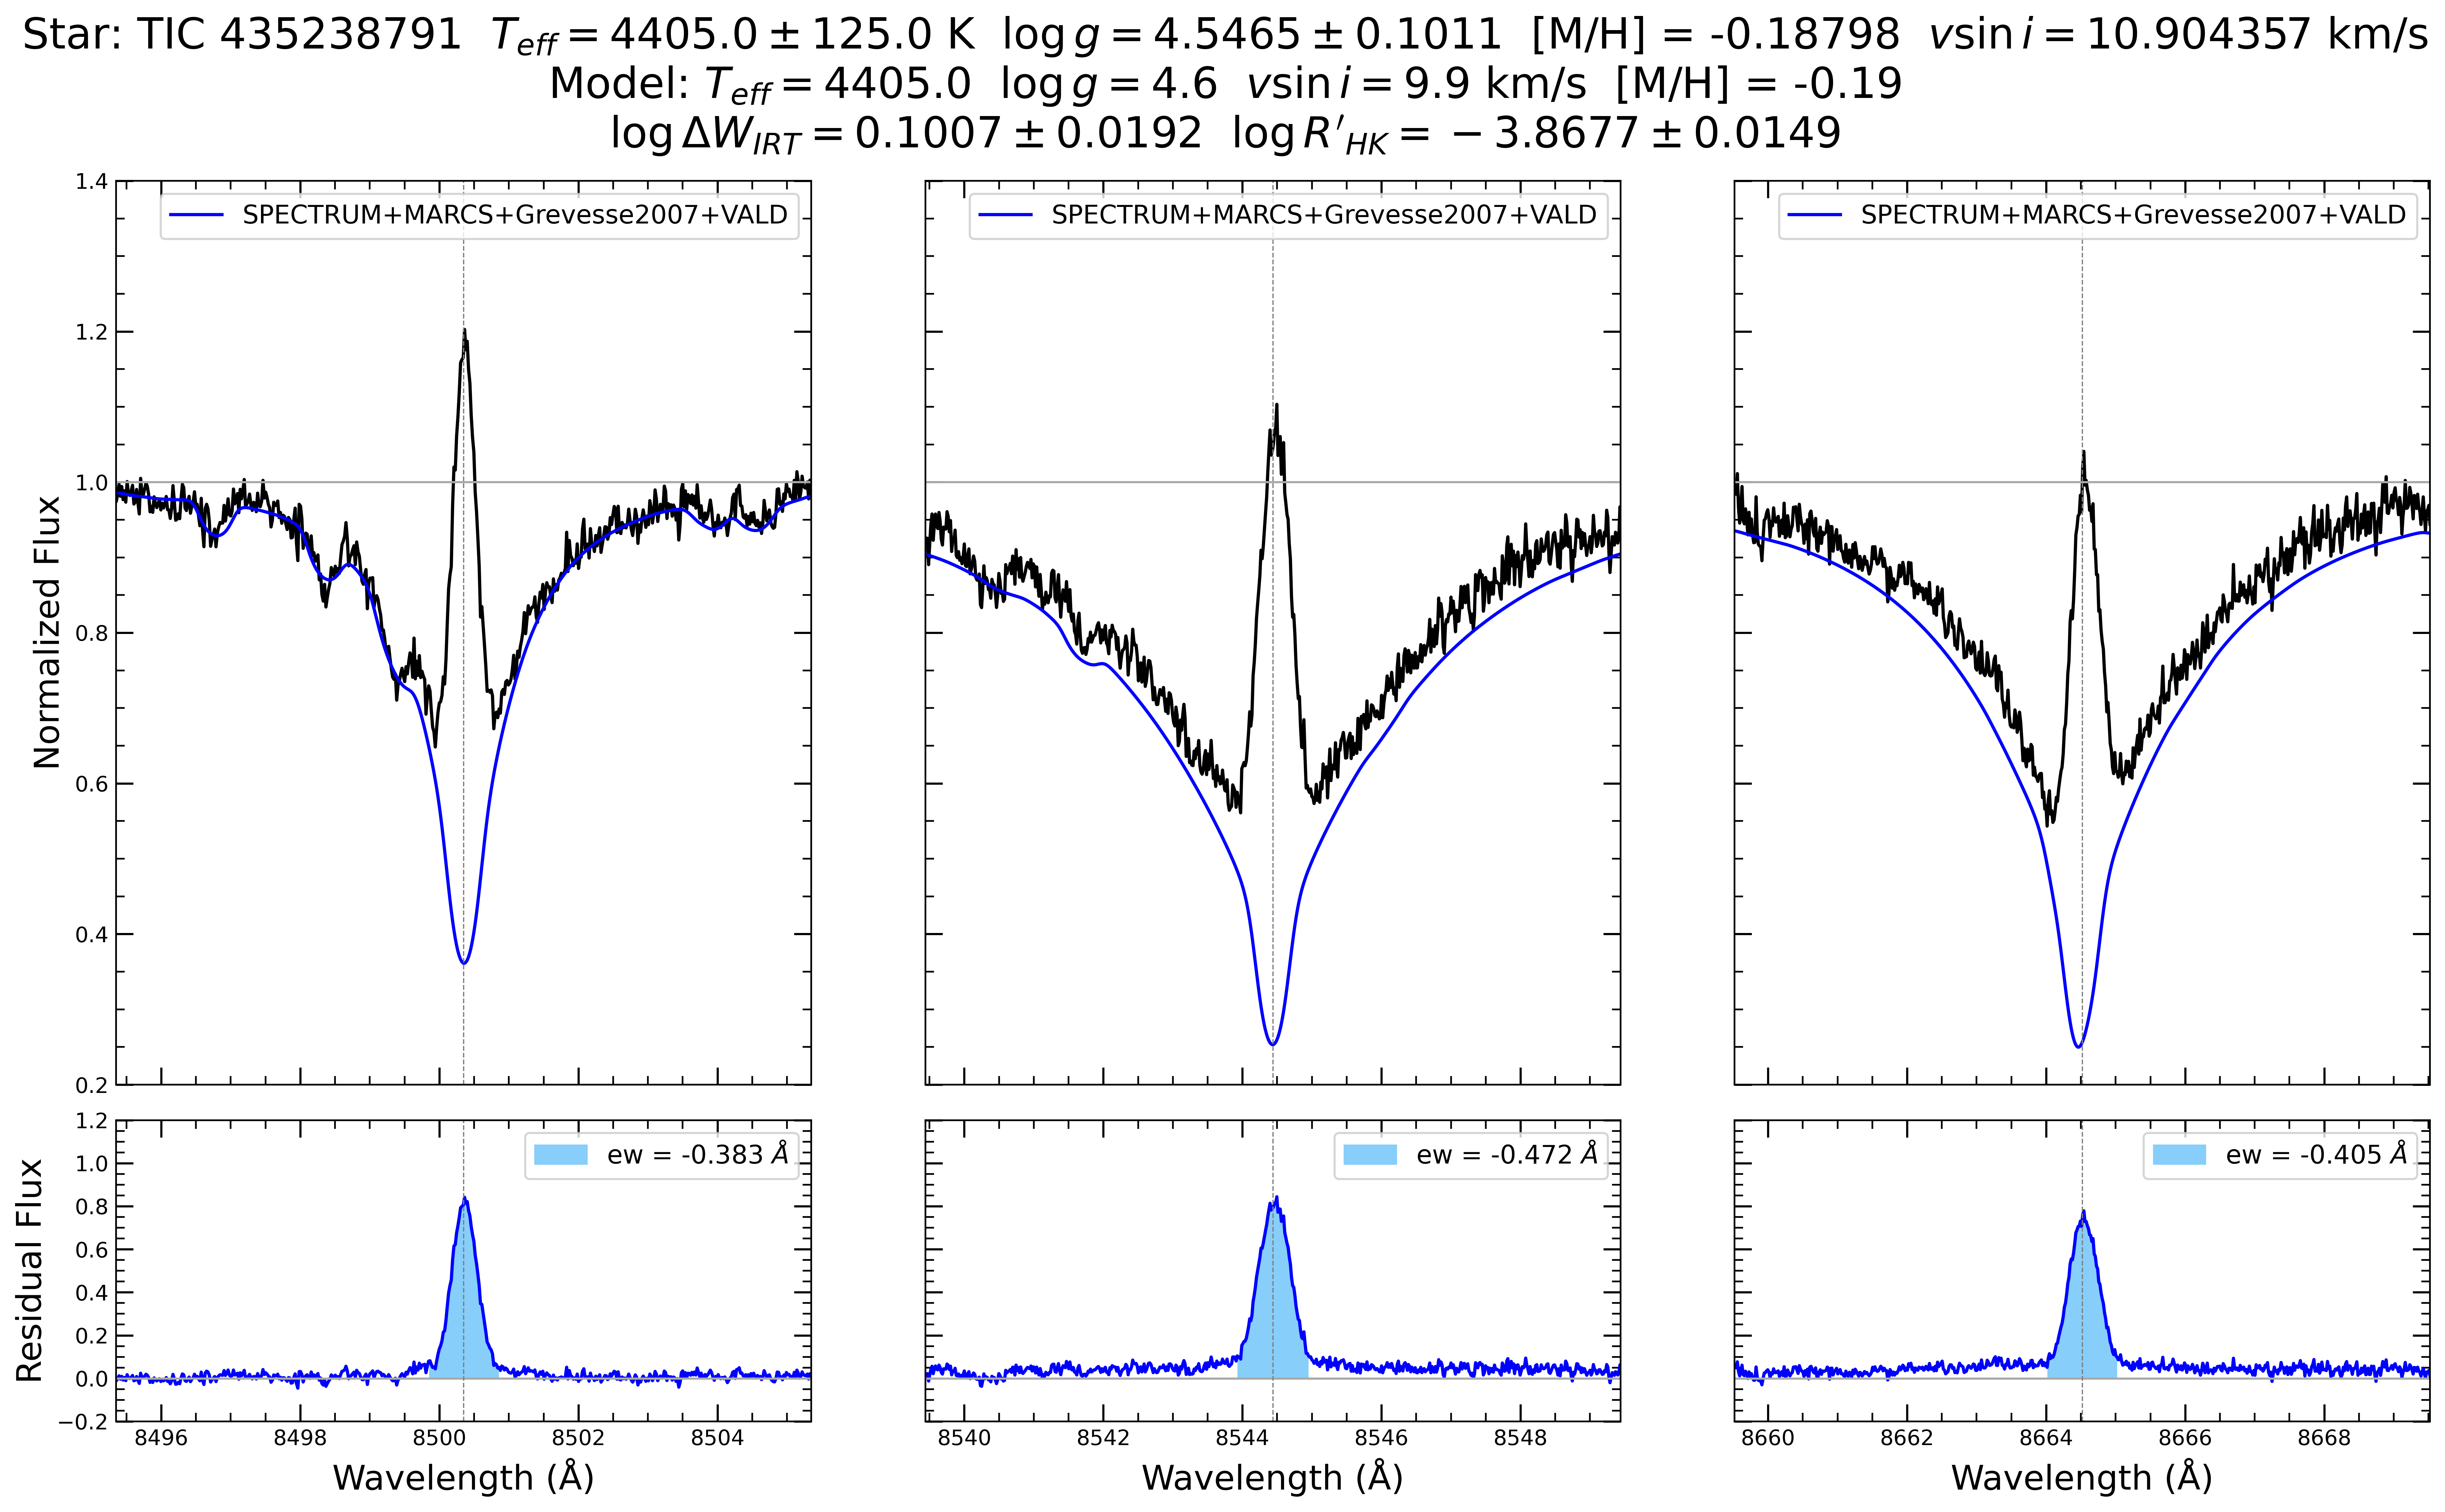

log_WIRT_total = 0.1007 Å  log_RHK_total = -3.8677
log_WIRT_err = 0.0192  log_HK_err = 0.0149
WIRT_total = 1.2609  RHK_total = 0.000136
WIRT_err = 0.0557  RHK_err = 0.000005


In [158]:
'''Plot Everything'''

fig, axes = plt.subplots(2, len(echelle_order), figsize=(16, 10), sharex='col', sharey='row', gridspec_kw={'height_ratios': [3, 1]}, dpi=500, squeeze=False)
# ew_list = []
ew_list = []
rms_values = []
stat_noise_list = []
alpha_list = []
for i, (order, vac, label) in enumerate(zip(echelle_order, vacuum, labels)):

    wavelengths, flux, header = get_spectral_order(folder_path, order)

    continuum_fit, lambda_valid, flux_valid, flux_norm = fit_spectrum(wavelengths, flux)

    wave3, flux3 = get_best_synth(best_model)
    # broadened = broaden_model(mod_wave, mod_flux, vac, vsini, lambda_valid, flux_norm)
    # diff = flux_norm - broadened
    # div = (flux_norm/broadened)
    diff3 = flux_norm - flux3
    div3 = (flux_norm/flux3)

    # ew = get_eqs(vac, lambda_valid, diff, div, window)
    ew = get_eqs(vac, lambda_valid, diff3, div3, window)
    # ew_list.append(ew.value)
    ew_list.append(ew.value)

    # rms = get_rms(lambda_valid, flux_norm, broadened, vac, window)
    rms3 = get_rms(lambda_valid, flux_norm, flux3, vac, window)
    rms_values.append(rms3)

    log_RHK, log_WIRT, WIRT, RHK = get_activity_indicator(vac, ew)

    stat_noise, S_N, center = get_errs(lambda_valid, flux_norm, flux3, vac, window, ew)
    stat_noise_list.append(stat_noise)

    ax1 = axes[0, i]   # top row
    ax2 = axes[1, i]   # bottom row
    # ax3 = axes[2, i] 

    ax1.plot(lambda_valid, flux_norm, color='black')
    # ax1.plot(lambda_valid, broadened, color='red', label = f'BT-Settl')
    ax1.plot(lambda_valid, flux3, color='blue', label = f'SPECTRUM+MARCS+Grevesse2007+VALD')
    ax1.axvline(vac, color='gray', linestyle='--', linewidth=0.6)
    ax1.axhline(1, color='darkgray', linewidth=1)
    ax1.set_xlim(vac - 5, vac + 5)
    ax1.set_ylim(0.2, 1.4)
    ax1.legend(fontsize=12)
    # ax1.set_title('labels')

    window_mask = (lambda_valid > vac - window/2) & (lambda_valid < vac + window/2)

    # ax2.plot(lambda_valid, diff, color='red', label = f'rms = {rms:.3f}')
    ax2.plot(lambda_valid, diff3, color='blue')
    ax2.axhline(0, color='darkgray', linewidth=1)
    ax2.axvline(vac, color='gray', linestyle='--', linewidth=0.6)
    # ax2.fill_between(lambda_valid[window_mask], diff[window_mask], 0, label=fr"ew = {ew.value:.3f} $\AA$", color = 'lightpink')
    ax2.fill_between(lambda_valid[window_mask], diff3[window_mask], 0, label=fr"ew = {ew.value:.3f} $\AA$", color = 'lightskyblue')
    ax2.set_xlim(vac - 5, vac + 5)
    ax2.set_ylim(-0.2, 1.2)
    ax2.legend(fontsize=12)

    # ax3.plot(lambda_valid, diff2, color='blue', label = f'rms2 = {rms2:.3f}')
    # ax3.axhline(0, color='darkgray', linewidth=1)
    # ax3.axvline(vac, color='gray', linestyle='--', linewidth=0.6)
    # ax3.fill_between(lambda_valid[window_mask], diff2[window_mask], 0, label=fr"ew2 = {ew2.value:.3f} $\AA$", color = 'lightskyblue')
    # ax3.set_xlim(vac - 5, vac + 5)
    # ax3.set_ylim(-0.2, 1.2)
    # ax3.legend(fontsize=12)

w = np.array([0.5, 1.0, 0.5])

ew_array = np.array(ew_list)
stat_noise_array = np.array(stat_noise_list)

WIRT_total = np.sum(np.abs(ew_array)) ########## take out abs and add negative to ew calculation
log_WIRT_total = np.log10(WIRT_total)

log_RHK_total = (log_WIRT_total - 5.09)/1.29
RHK_total = 10**log_RHK_total
WIRT_err_total = np.sqrt((window**2)*(np.sum((w**2)*(stat_noise_array))))
log_WIRT_err = WIRT_err_total / (WIRT_total * np.log(10))
log_RHK_err = log_WIRT_err / 1.29
RHK_err = np.log(10) * RHK_total * log_RHK_err



fig.suptitle(fr"Star: {header['OBJECT']}  $T_{{eff}} = {teff} \pm {teff_err}$ K  $\log g = {logg} \pm {logg_err}$  [M/H] = {MH}  $v\sin i = {vsini}$ km/s" 
    "\n" fr"Model: $T_{{eff}} = {best['Teff']}$  $\log g = {best['logg']}$  $v\sin i = {best['vsini']}$ km/s  [M/H] = {best['MH']}"
    "\n" fr"$\log \Delta W_{{IRT}} = {log_WIRT_total:.4f} \pm {log_WIRT_err:.4f}$  $\log R'_{{HK}} = {log_RHK_total:.4f} \pm {log_RHK_err:.4f}$",
    fontsize=20)

for ax in axes[1, :]:
    ax.set_xlabel("Wavelength (Å)", fontsize=16)
    axes[0, 0].set_ylabel("Normalized Flux", fontsize=16)
    axes[1, 0].set_ylabel("Residual Flux", fontsize=16)
    # axes[2, 0].set_ylabel("Residual Flux", fontsize=16)

for ax in axes.flatten():
    ax.minorticks_on()

    ax.tick_params(
        axis='both',
        which='major',
        direction='in', 
        top=True,
        right=True,
        bottom=True,
        left=True,
        length=8,
        width=1
    )

    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',      
        top=True,
        right=True,
        bottom=True,
        left=True,
        length=4,
        width=0.8
    )

    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

print(f"log_WIRT_total = {log_WIRT_total:.4f} Å  log_RHK_total = {log_RHK_total:.4f}\nlog_WIRT_err = {log_WIRT_err:.4f}  log_HK_err = {log_RHK_err:.4f}\nWIRT_total = {WIRT_total:.4f}  RHK_total = {RHK_total:.6f}\nWIRT_err = {WIRT_err_total:.4f}  RHK_err = {RHK_err:.6f}")


In [32]:
air = 5848.127 
s = 10**4/air
n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
vac = air * n
print(vac)

5849.7481979032855
